# Beta Diversity: Turnover and Nestedness Decomposition

## Overview

Beta diversity quantifies the variation in species composition among sites. A crucial advance in community ecology was the recognition that total beta diversity can be decomposed into two ecologically distinct components:

| Component | Meaning | Ecological Driver |
|---|---|---|
| **Turnover** (replacement) | Species at one site are *replaced* by different species at another — same richness, different identities | Environmental gradients, dispersal barriers, competitive exclusion |
| **Nestedness** (richness gradient) | Species-poor sites are subsets of species-rich sites — composition differences arise from species loss | Habitat degradation, island biogeography, extinction filters |

**Why this decomposition matters:**  
PERMANOVA and NMDS detect that communities differ — but not *why*. If beta diversity is driven by nestedness, species-poor (often degraded) sites have lost species from the reference pool. If driven by turnover, communities are genuinely different in identity. These have fundamentally different conservation and management implications.

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | Is the degraded-site community a nested subset of the reference community (species loss) or does it have genuinely different species (replacement)? |
| **Healthcare** | Is the disease-state microbiome a depleted version of the healthy microbiome, or does it contain different taxa? |
| **Conservation** | Which patches in a fragmented landscape are nested subsets of larger patches vs. supporting unique species assemblages? |

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(vegan)
library(betapart)    # betapart.core(), beta.multi(), beta.pair()
library(patchwork)

set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'vegan' was built under R version 4.4.3"
Loading required package: permute

Warning message:
"package 'beta

## Data

We simulate three habitat types with deliberately different beta diversity structures: reference sites (high turnover along a gradient), degraded sites (nestedness dominant — degraded sites have lost species from the reference pool), and restored sites (intermediate).

In [2]:
n_sites <- 15; n_sp <- 25

# Reference: moderate turnover along environmental gradient
ref_base <- rbinom(n_sp, 1, 0.6)  # baseline presence
ref_comm <- t(replicate(n_sites, {
  p <- plogis(qlogis(ref_base + 0.01) + rnorm(n_sp, 0, 1.2))
  rbinom(n_sp, 1, p)
}))

# Degraded: nested subsets — randomly remove species from reference
deg_comm <- t(replicate(n_sites, {
  keep <- rbinom(n_sp, 1, 0.45)   # retain ~45% of species pool
  ref_base * keep
}))

# Restored: partial recovery — more species than degraded, some turnover
rest_comm <- t(replicate(n_sites, {
  keep <- rbinom(n_sp, 1, 0.60)
  new  <- rbinom(n_sp, 1, 0.10)   # some novel species
  pmin(ref_base * keep + new, 1L)
}))

rownames(ref_comm)  <- paste0("ref",  1:n_sites)
rownames(deg_comm)  <- paste0("deg",  1:n_sites)
rownames(rest_comm) <- paste0("rest", 1:n_sites)
colnames(ref_comm) <- colnames(deg_comm) <- colnames(rest_comm) <- paste0("sp", 1:n_sp)

# Full community matrix
all_comm <- rbind(ref_comm, deg_comm, rest_comm)
habitat  <- factor(rep(c("reference", "degraded", "restored"), each = n_sites),
                   levels = c("reference", "degraded", "restored"))

cat(sprintf("Community matrix: %d sites × %d species\n", nrow(all_comm), ncol(all_comm)))
cat(sprintf("Mean species richness: ref=%.1f  deg=%.1f  rest=%.1f\n",
            mean(rowSums(ref_comm)), mean(rowSums(deg_comm)), mean(rowSums(rest_comm))))

Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_sp, 1, p):
"NAs produced"
Warning message in qlogis(ref_base + 0.01):
"NaNs produced"
Warning message in rbinom(n_

Community matrix: 45 sites × 25 species
Mean species richness: ref=NA  deg=4.9  rest=8.4


---

## Multiple-Site Beta Diversity

`betapart::beta.multi()` computes total beta diversity and its turnover/nestedness components for a single group of sites.

In [11]:
# ── Convert presence/absence, replacing NAs with 0 (absent) ──────────────────
# NA in a community matrix = species not recorded = absent
ref_pa  <- as.matrix(replace(ref_comm,  is.na(ref_comm),  0))
deg_pa  <- as.matrix(replace(deg_comm,  is.na(deg_comm),  0))
rest_pa <- as.matrix(replace(rest_comm, is.na(rest_comm), 0))

# ── Sørensen family: presence/absence ────────────────────────────────────────
# Sørensen total = turnover (Simpson) + nestedness-resultant
beta_ref  <- betapart::beta.multi(ref_pa,  index.family = "sorensen")
beta_deg  <- betapart::beta.multi(deg_pa,  index.family = "sorensen")
beta_rest <- betapart::beta.multi(rest_pa, index.family = "sorensen")

# ── Compare across habitats ───────────────────────────────────────────────────
beta_summary <- tibble(
  habitat    = c("reference", "degraded", "restored"),
  beta_total = c(beta_ref$beta.SOR,  beta_deg$beta.SOR,  beta_rest$beta.SOR),
  turnover   = c(beta_ref$beta.SIM,  beta_deg$beta.SIM,  beta_rest$beta.SIM),
  nestedness = c(beta_ref$beta.SNE,  beta_deg$beta.SNE,  beta_rest$beta.SNE)
) %>%
  mutate(pct_turnover   = round(turnover   / beta_total * 100, 1),
         pct_nestedness = round(nestedness / beta_total * 100, 1))

print(beta_summary)
# Reference: expect higher turnover fraction
# Degraded:  expect higher nestedness fraction (species loss dominant)

# ── Bray-Curtis family: abundance-based ──────────────────────────────────────
# betapart.core.abund checks is.numeric() which fails on integer matrices
# Coerce to data frame of doubles — matches the BCI example in the docs

ref_comm_abund  <- as.data.frame(apply(ref_comm,  2, as.numeric))
deg_comm_abund  <- as.data.frame(apply(deg_comm,  2, as.numeric))
rest_comm_abund <- as.data.frame(apply(rest_comm, 2, as.numeric))

# Replace NAs with 0
ref_comm_abund[is.na(ref_comm_abund)]   <- 0
deg_comm_abund[is.na(deg_comm_abund)]   <- 0
rest_comm_abund[is.na(rest_comm_abund)] <- 0

# Call beta.multi.abund directly — no need for bray.part() intermediary
betapart::beta.multi.abund(ref_comm_abund,  index.family = "bray")
betapart::beta.multi.abund(deg_comm_abund,  index.family = "bray")
betapart::beta.multi.abund(rest_comm_abund, index.family = "bray")

# A tibble: 3 × 6
  habitat   beta_total turnover nestedness pct_turnover pct_nestedness
  <chr>          <dbl>    <dbl>      <dbl>        <dbl>          <dbl>
1 reference      1        1         0             100              0  
2 degraded       0.823    0.768     0.0555         93.3            6.7
3 restored       0.804    0.766     0.0383         95.2            4.8


$beta.BRAY.BAL
[1] 1

$beta.BRAY.GRA
[1] 0

$beta.BRAY
[1] 1

$beta.BRAY.BAL
[1] 0.7675277

$beta.BRAY.GRA
[1] 0.05550603

$beta.BRAY
[1] 0.8230337

$beta.BRAY.BAL
[1] 0.7655172

$beta.BRAY.GRA
[1] 0.03832891

$beta.BRAY
[1] 0.8038462

---

## Pairwise Beta Diversity Matrices

`beta.pair()` returns three pairwise distance matrices: total beta, turnover component, and nestedness component. These can be passed directly to NMDS or PERMANOVA.

In [14]:
# ── Remove empty sites (all-zero rows) before conversion ─────────────────────
all_comm_clean <- all_comm[rowSums(all_comm, na.rm = TRUE) > 0, ]
habitat_clean  <- habitat[rowSums(all_comm, na.rm = TRUE) > 0]

# ── Convert to presence/absence ───────────────────────────────────────────────
all_comm_pa <- (as.matrix(replace(all_comm_clean, is.na(all_comm_clean), 0)) > 0) * 1L

# Verify no empty rows remain
stopifnot(all(rowSums(all_comm_pa) > 0))

# ── Pairwise decomposition for all sites ─────────────────────────────────────
beta_pair <- betapart::beta.pair(all_comm_pa, index.family = "sorensen")

str(beta_pair)

# ── NMDS on each component ────────────────────────────────────────────────────
nmds_total    <- vegan::metaMDS(beta_pair$beta.sor, k = 2, trymax = 100, trace = 0)
nmds_turnover <- vegan::metaMDS(beta_pair$beta.sim, k = 2, trymax = 100, trace = 0)
nmds_nested   <- vegan::metaMDS(beta_pair$beta.sne, k = 2, trymax = 100, trace = 0)

cat(sprintf("Stress: total=%.3f  turnover=%.3f  nestedness=%.3f\n",
            nmds_total$stress, nmds_turnover$stress, nmds_nested$stress))

# ── PERMANOVA on each component ───────────────────────────────────────────────
sites_df <- tibble(habitat = habitat_clean)

perm_total    <- vegan::adonis2(beta_pair$beta.sor ~ habitat, data = sites_df, permutations = 999, by = "margin")
perm_turnover <- vegan::adonis2(beta_pair$beta.sim ~ habitat, data = sites_df, permutations = 999, by = "margin")
perm_nested   <- vegan::adonis2(beta_pair$beta.sne ~ habitat, data = sites_df, permutations = 999, by = "margin")

tibble(
  component = c("Total (Sørensen)", "Turnover (Simpson)", "Nestedness"),
  R2        = c(perm_total$R2[1], perm_turnover$R2[1], perm_nested$R2[1]),
  F         = c(perm_total$F[1],  perm_turnover$F[1],  perm_nested$F[1]),
  p         = c(perm_total$`Pr(>F)`[1], perm_turnover$`Pr(>F)`[1], perm_nested$`Pr(>F)`[1])
) %>% mutate(across(where(is.numeric), ~ round(.x, 4))) %>% print()
# Compare: which component drives between-group differences?

List of 3
 $ beta.sim: 'dist' num [1:528] 1 1 1 1 1 1 1 1 1 1 ...
  ..- attr(*, "Labels")= chr [1:33] "ref6" "ref9" "ref14" "deg1" ...
  ..- attr(*, "Size")= int 33
  ..- attr(*, "call")= language as.dist.default(m = beta.sim)
  ..- attr(*, "Diag")= logi FALSE
  ..- attr(*, "Upper")= logi FALSE
 $ beta.sne: 'dist' num [1:528] 0 0 0 0 0 0 0 0 0 0 ...
  ..- attr(*, "Labels")= chr [1:33] "ref6" "ref9" "ref14" "deg1" ...
  ..- attr(*, "Size")= int 33
  ..- attr(*, "call")= language as.dist.default(m = beta.sne)
  ..- attr(*, "Diag")= logi FALSE
  ..- attr(*, "Upper")= logi FALSE
 $ beta.sor: 'dist' num [1:528] 1 1 1 1 1 1 1 1 1 1 ...
  ..- attr(*, "Labels")= chr [1:33] "ref6" "ref9" "ref14" "deg1" ...
  ..- attr(*, "Size")= int 33
  ..- attr(*, "call")= language as.dist.default(m = beta.sor)
  ..- attr(*, "Diag")= logi FALSE
  ..- attr(*, "Upper")= logi FALSE


Stress: total=0.132  turnover=0.157  nestedness=0.174
# A tibble: 3 × 4
  component             R2     F     p
  <chr>              <dbl> <dbl> <dbl>
1 Total (Sørensen)   0.214  4.08 0.002
2 Turnover (Simpson) 0.165  2.96 0.009
3 Nestedness         0.717 38.1  0.001


---

## Visualizing Beta Diversity Components

Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."
Too few points to calculate an ellipse
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_path()`)."


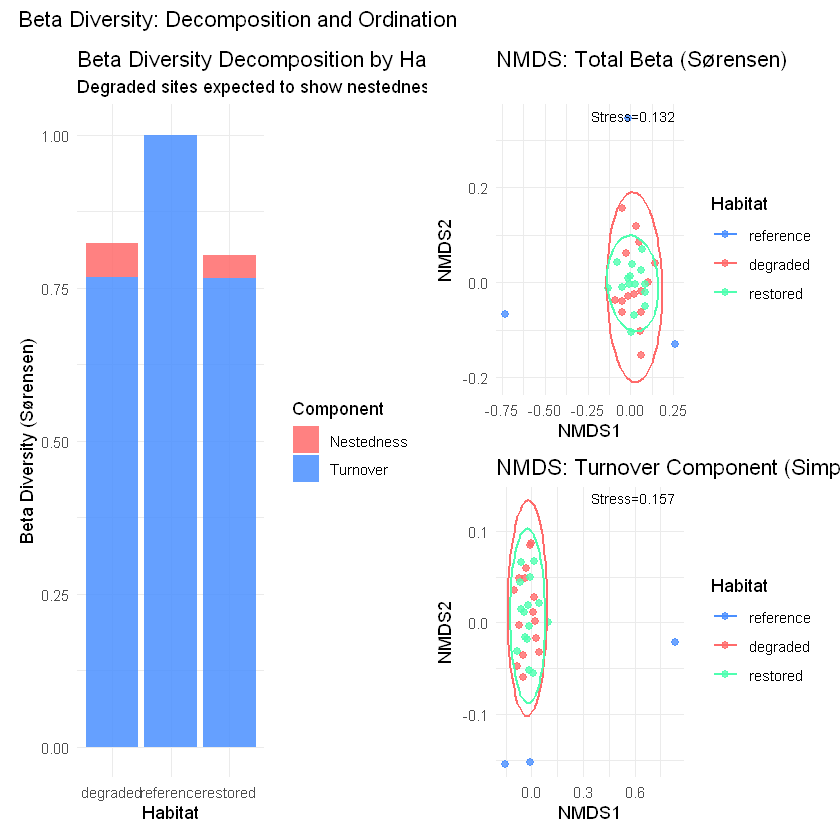

In [16]:
# ── Stacked bar: turnover vs. nestedness by habitat ───────────────────────────
beta_summary %>%
  select(habitat, turnover, nestedness) %>%
  pivot_longer(c(turnover, nestedness), names_to = "component", values_to = "value") %>%
  ggplot(aes(x = habitat, y = value, fill = component)) +
  geom_col(position = "stack", alpha = 0.85) +
  scale_fill_manual(values = c(nestedness = "#ff6b6b", turnover = "#4a8fff"),
                    labels  = c("Nestedness", "Turnover")) +
  labs(title = "Beta Diversity Decomposition by Habitat",
       subtitle = "Degraded sites expected to show nestedness dominance (species loss)",
       x = "Habitat", y = "Beta Diversity (Sørensen)", fill = "Component") +
  theme_minimal() -> p_stack

# ── NMDS comparison: total vs. turnover component ────────────────────────────
# Use habitat_clean — filtered to match the non-empty sites in the distance matrix
make_nmds_df <- function(nmds_obj, hab) {
  as.data.frame(vegan::scores(nmds_obj, display = "sites")) %>%
    mutate(habitat = hab)
}

nmds_total_df    <- make_nmds_df(nmds_total,    habitat_clean)
nmds_turnover_df <- make_nmds_df(nmds_turnover, habitat_clean)

p_total <- ggplot(nmds_total_df, aes(x = NMDS1, y = NMDS2, color = habitat)) +
  geom_point(size = 2, alpha = 0.8) +
  stat_ellipse(level = 0.95, linewidth = 0.7) +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  annotate("text", x = Inf, y = Inf,
           label = sprintf("Stress=%.3f", nmds_total$stress),
           hjust = 1.1, vjust = 1.5, size = 3) +
  labs(title = "NMDS: Total Beta (Sørensen)", color = "Habitat") +
  theme_minimal()

p_turn <- ggplot(nmds_turnover_df, aes(x = NMDS1, y = NMDS2, color = habitat)) +
  geom_point(size = 2, alpha = 0.8) +
  stat_ellipse(level = 0.95, linewidth = 0.7) +
  scale_color_manual(values = c("#4a8fff", "#ff6b6b", "#4fffb0")) +
  annotate("text", x = Inf, y = Inf,
           label = sprintf("Stress=%.3f", nmds_turnover$stress),
           hjust = 1.1, vjust = 1.5, size = 3) +
  labs(title = "NMDS: Turnover Component (Simpson)", color = "Habitat") +
  theme_minimal()

(p_stack | (p_total / p_turn)) +
  patchwork::plot_annotation(
    title = "Beta Diversity: Decomposition and Ordination"
  )

---

## Reporting Results

In [17]:
print(beta_summary)

# Standard reporting format:
# "Beta diversity was decomposed into turnover and nestedness components
#  using the betapart package (Baselga & Orme 2012). Reference sites
#  showed high total beta diversity (β_SOR = X.XX), predominantly driven
#  by species turnover (β_SIM = X.XX; XX% of total). Degraded sites
#  showed lower total beta diversity (β_SOR = X.XX) with a higher
#  nestedness fraction (β_SNE = X.XX; XX%), consistent with species loss
#  from a shared reference pool rather than replacement by different
#  species. PERMANOVA on the turnover component indicated significant
#  habitat differences (F = X.XX, R² = X.XX, p = .XXX), while the
#  nestedness component was [significant/non-significant]
#  (F = X.XX, R² = X.XX, p = .XXX)."
#
# Cite: Baselga A & Orme CDL (2012) betapart: an R package for the
# study of beta diversity. Methods in Ecology and Evolution 3:808-812.

# A tibble: 3 × 6
  habitat   beta_total turnover nestedness pct_turnover pct_nestedness
  <chr>          <dbl>    <dbl>      <dbl>        <dbl>          <dbl>
1 reference      1        1         0             100              0  
2 degraded       0.823    0.768     0.0555         93.3            6.7
3 restored       0.804    0.766     0.0383         95.2            4.8


---

## Common Pitfalls

**1. Using only total beta diversity**  
Total beta diversity (Sørensen or Bray-Curtis) conflates turnover and nestedness. Two groups can have identical total beta diversity but completely different ecological stories. Always decompose.

**2. Applying to abundance data without the quantitative extension**  
The standard `beta.pair()` uses presence/absence. For abundance data, use `betapart::bray.part()` which decomposes Bray-Curtis dissimilarity into balanced variation and abundance gradient components.

**3. Confusing nestedness-resultant with strict nestedness**  
The nestedness-resultant component (β_SNE) is the fraction of total dissimilarity attributable to richness differences — not a test of strict nestedness pattern. For testing whether a nested structure exists, use `vegan::nestedtemp()` or `nestednodf()`.

**4. Not running PERMANOVA on each component separately**  
Running PERMANOVA only on total beta diversity masks whether habitat differences are driven by turnover, nestedness, or both. Always test each component separately with `adonis2()`.

**5. Interpreting high nestedness as habitat degradation without further evidence**  
Nestedness can arise from degradation (species loss) but also from natural processes like island biogeography or passive sampling. Pair with environmental gradient analysis (dbRDA) to confirm the mechanism.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*